In [1]:
import numpy as np

def create_weight_matrix(patterns):
    """
    Stores patterns in a Hopfield Network using Hebbian learning.
    Expects a list of bipolar arrays (1, -1).
    """
    # Determine the number of units (N) in the network
    num_units = len(patterns[0])
    print("Number of Units\n",num_units)
    # Initialize an N x N weight matrix with zeros
    weights = np.zeros((num_units, num_units))

    # Apply Hebbian Learning: W = sum(x * x^T)
    for p in patterns:
        # Convert list to a column vector for matrix multiplication
        pattern_vector = np.array(p).reshape(-1, 1)
        print("Reshaped_Pattern\n", pattern_vector)

        # Add the outer product of the pattern to the weight matrix
        # This mathematically executes the Δwij = si * sj rule
        weights += np.dot(pattern_vector, pattern_vector.T)
        print("Weight Matrix after each pattern learning\n",weights)

    # Enforce no self-connections by setting the diagonal to 0
    np.fill_diagonal(weights, 0)
    print("Weight Matrix\n",weights)

    # Normalize the weights by the total number of units
    weights = weights / num_units

    return weights



In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns



def visualize_hopfield_weights(weight_matrix):
    """
    Generates two visualizations for the Hopfield Network weights:
    1. A Heatmap of the weight matrix.
    2. A Node-Edge graph showing network topology.
    """
    num_units = weight_matrix.shape[0]

    # Set up a side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Hopfield Network Weight Visualization", fontsize=16)

    # ---------------------------------------------------------
    # Visualization 1: Weight Matrix Heatmap
    # ---------------------------------------------------------
    sns.heatmap(weight_matrix, annot=True, cmap='coolwarm', center=0,
                ax=axes[0], cbar_kws={'label': 'Weight Value'},
                linewidths=1, linecolor='black')
    axes[0].set_title("Weight Matrix (Heatmap)")
    axes[0].set_xlabel("Neuron j")
    axes[0].set_ylabel("Neuron i")

    # ---------------------------------------------------------
    # Visualization 2: Network Topology Graph
    # ---------------------------------------------------------
    G = nx.Graph()
    G.add_nodes_from(range(num_units))

    # Add edges to the graph based on the weight matrix
    # Since the matrix is symmetric, we only need the upper triangle
    for i in range(num_units):
        for j in range(i + 1, num_units):
            weight = weight_matrix[i, j]
            if weight != 0:
                G.add_edge(i, j, weight=weight)

    # Use a circular layout to cleanly separate the neurons
    pos = nx.circular_layout(G)

    # Extract edge weights to determine line thickness and color
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]

    # Green for positive (Hebbian), Red for negative (Anti-Hebbian)
    edge_colors = ['green' if w > 0 else 'red' for w in weights]
    # Scale line width by absolute weight value for visual emphasis
    edge_widths = [abs(w) * 4 for w in weights]

    # Draw the network components
    nx.draw_networkx_nodes(G, pos, ax=axes[1], node_size=1000,
                           node_color='lightblue', edgecolors='black')
    nx.draw_networkx_labels(G, pos, ax=axes[1], font_size=14, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=axes[1], edgelist=edges,
                           width=edge_widths, edge_color=edge_colors)

    # Add numeric labels directly on the edges
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in edges}
    nx.draw_networkx_edge_labels(G, pos, ax=axes[1], edge_labels=edge_labels, font_size=10)

    axes[1].set_title("Network Topology (Green = +, Red = -)")
    axes[1].axis("off") # Hide gridlines for the graph

    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage:
# ==========================================
pattern_A = [1, -1, 1, -1]
pattern_B = [-1, 1, -1, 1]
training_patterns = [pattern_A, pattern_B]



Input training_Patterns
 [[1, -1, 1, -1], [-1, 1, -1, 1]]
Number of Units
 4
Reshaped_Pattern
 [[ 1]
 [-1]
 [ 1]
 [-1]]
Weight Matrix after each pattern learning
 [[ 1. -1.  1. -1.]
 [-1.  1. -1.  1.]
 [ 1. -1.  1. -1.]
 [-1.  1. -1.  1.]]
Reshaped_Pattern
 [[-1]
 [ 1]
 [-1]
 [ 1]]
Weight Matrix after each pattern learning
 [[ 2. -2.  2. -2.]
 [-2.  2. -2.  2.]
 [ 2. -2.  2. -2.]
 [-2.  2. -2.  2.]]
Weight Matrix
 [[ 0. -2.  2. -2.]
 [-2.  0. -2.  2.]
 [ 2. -2.  0. -2.]
 [-2.  2. -2.  0.]]
Learned Weight Matrix (W):
[[ 0.  -0.5  0.5 -0.5]
 [-0.5  0.  -0.5  0.5]
 [ 0.5 -0.5  0.  -0.5]
 [-0.5  0.5 -0.5  0. ]]


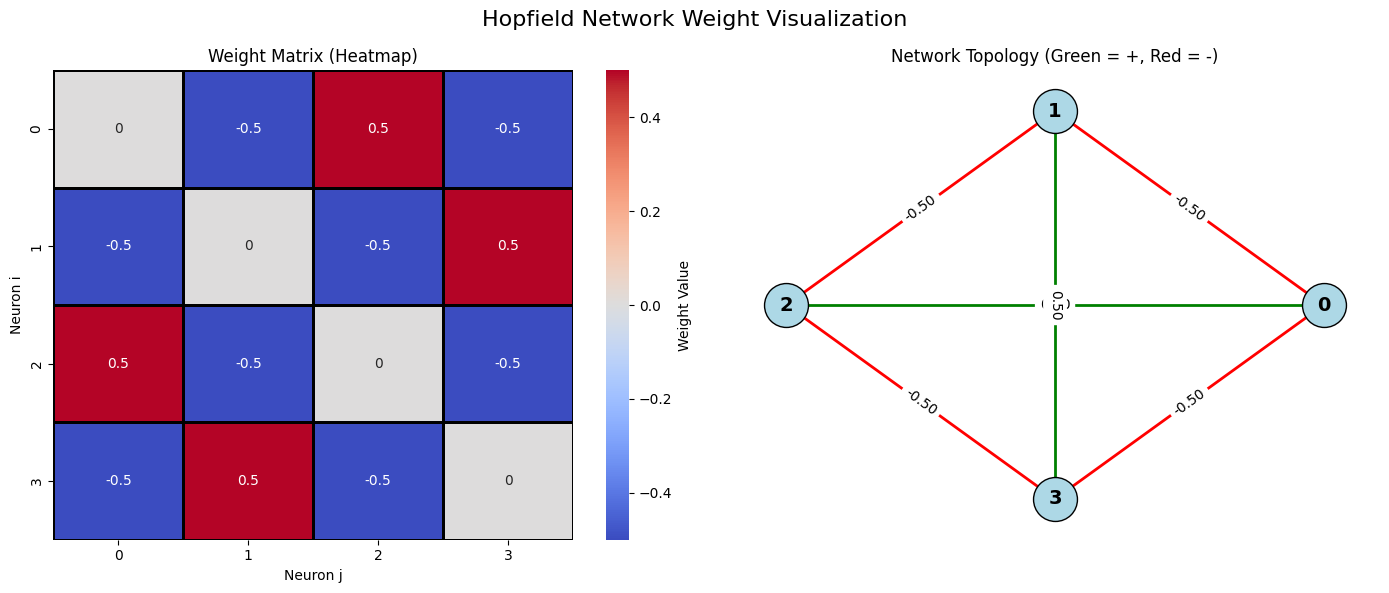

In [3]:
# ==========================================
# Example Usage:
# ==========================================

# Define a 4-unit network with two patterns to memorize
# (Using bipolar states 1 and -1)
pattern_A = [1, -1, 1, -1]
pattern_B = [-1, 1, -1, 1]

training_patterns = [pattern_A, pattern_B]
print("Input training_Patterns\n",training_patterns)

# Compute the weight matrix that stores these patterns
W = create_weight_matrix(training_patterns)

print("Learned Weight Matrix (W):")
print(W)
# Visualize!
visualize_hopfield_weights(W)

Input training_Patterns\n [[1, 1, -1, -1, -1], [-1, -1, 1, 1, 1]]
Number of Units
 5
Reshaped_Pattern
 [[ 1]
 [ 1]
 [-1]
 [-1]
 [-1]]
Weight Matrix after each pattern learning
 [[ 1.  1. -1. -1. -1.]
 [ 1.  1. -1. -1. -1.]
 [-1. -1.  1.  1.  1.]
 [-1. -1.  1.  1.  1.]
 [-1. -1.  1.  1.  1.]]
Reshaped_Pattern
 [[-1]
 [-1]
 [ 1]
 [ 1]
 [ 1]]
Weight Matrix after each pattern learning
 [[ 2.  2. -2. -2. -2.]
 [ 2.  2. -2. -2. -2.]
 [-2. -2.  2.  2.  2.]
 [-2. -2.  2.  2.  2.]
 [-2. -2.  2.  2.  2.]]
Weight Matrix
 [[ 0.  2. -2. -2. -2.]
 [ 2.  0. -2. -2. -2.]
 [-2. -2.  0.  2.  2.]
 [-2. -2.  2.  0.  2.]
 [-2. -2.  2.  2.  0.]]
Learned Weight Matrix (W):
[[ 0.   0.4 -0.4 -0.4 -0.4]
 [ 0.4  0.  -0.4 -0.4 -0.4]
 [-0.4 -0.4  0.   0.4  0.4]
 [-0.4 -0.4  0.4  0.   0.4]
 [-0.4 -0.4  0.4  0.4  0. ]]


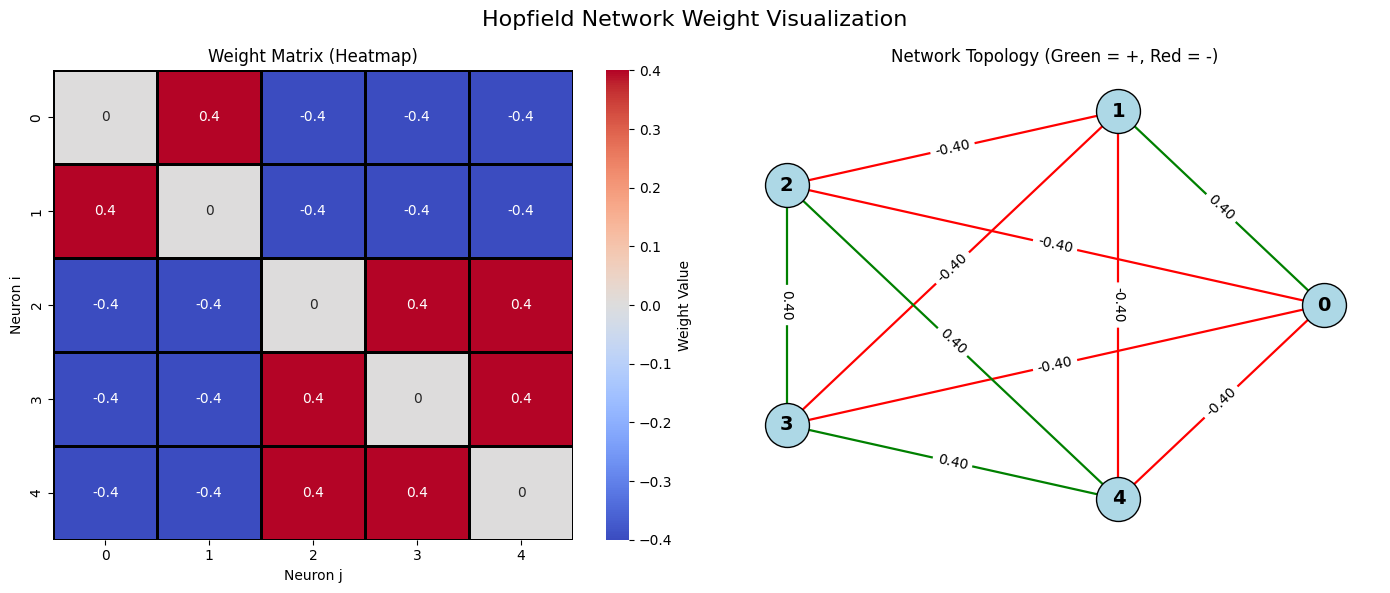

In [4]:
# ==========================================
# Example Usage 2:
# ==========================================

# Define a 4-unit network with two patterns to memorize
# (Using bipolar states 1 and -1)
pattern_A = [1,1, -1, -1, -1]
pattern_B = [-1, -1, 1, 1, 1]

training_patterns = [pattern_A, pattern_B]
print("Input training_Patterns\\n",training_patterns)

# Compute the weight matrix that stores these patterns
W = create_weight_matrix(training_patterns)

print("Learned Weight Matrix (W):")
print(W)
# Visualize!
visualize_hopfield_weights(W)

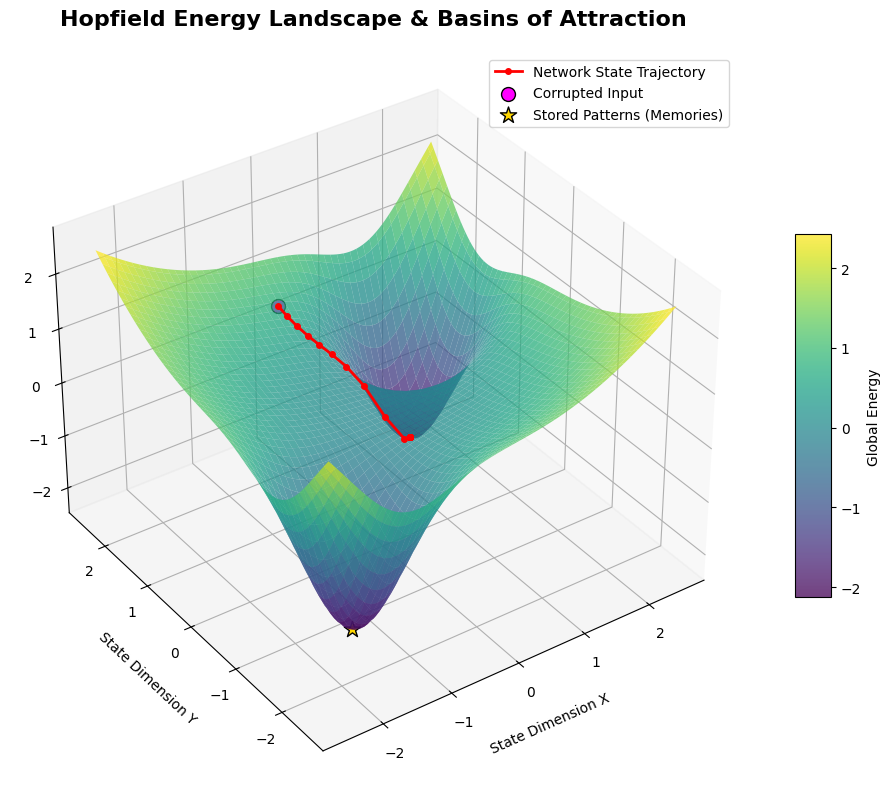

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Set up the figure and 3D axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Create a continuous 2D state space
# (A conceptual 2D projection of an N-dimensional state space)
X = np.linspace(-2.5, 2.5, 100)
Y = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(X, Y)

# 2. Define the Conceptual Energy Landscape
# We simulate two stored patterns as deep Gaussian "wells" (basins of attraction)
# Pattern A is stored near (1.5, 1.5) and Pattern B near (-1.5, -1.5)
def energy_function(x, y):
    basin_A = -3.0 * np.exp(-((x - 1.5)**2 + (y - 1.5)**2) / 0.8)
    basin_B = -3.0 * np.exp(-((x + 1.5)**2 + (y + 1.5)**2) / 0.8)
    # Add a slight convex bowl shape to ensure the outer edges slope inward
    global_bowl = 0.2 * (x**2 + y**2)
    return basin_A + basin_B + global_bowl

# Calculate energy for every point on the grid
Z = energy_function(X, Y)

# 3. Plot the 3D Surface
surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.75,
                       linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Global Energy')

# 4. Simulate a network "settling" (Trajectory via Gradient Descent)
# We start with a highly corrupted pattern (e.g., noise dropped high on a hill)
start_x, start_y = -0.2, 2.0
trajectory_x, trajectory_y, trajectory_z = [start_x], [start_y], [energy_function(start_x, start_y)]

# Use simple gradient descent to simulate the asynchronous update rule
# moving the network strictly downhill towards lower energy
curr_x, curr_y = start_x, start_y
learning_rate = 0.15

for _ in range(25):
    # Approximate the gradients (partial derivatives)
    dx = (energy_function(curr_x + 0.01, curr_y) - energy_function(curr_x, curr_y)) / 0.01
    dy = (energy_function(curr_x, curr_y + 0.01) - energy_function(curr_x, curr_y)) / 0.01

    # Update the state by moving in the opposite direction of the gradient
    curr_x -= learning_rate * dx
    curr_y -= learning_rate * dy

    trajectory_x.append(curr_x)
    trajectory_y.append(curr_y)
    trajectory_z.append(energy_function(curr_x, curr_y))

# 5. Plot the Trajectory and the Target Minima
# Plot the path the network takes
ax.plot(trajectory_x, trajectory_y, trajectory_z, color='red', marker='o',
        markersize=4, linewidth=2, label='Network State Trajectory', zorder=10)

# Plot the start point (corrupted input)
ax.scatter([start_x], [start_y], [energy_function(start_x, start_y)],
           color='magenta', s=100, edgecolor='black', label='Corrupted Input', zorder=11)

# Plot the stored patterns (the true local minima)
ax.scatter([1.5, -1.5], [1.5, -1.5], [energy_function(1.5, 1.5), energy_function(-1.5, -1.5)],
           color='gold', s=150, edgecolor='black', marker='*', label='Stored Patterns (Memories)', zorder=12)

# 6. Final Formatting
ax.set_title("Hopfield Energy Landscape & Basins of Attraction", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("State Dimension X", labelpad=10)
ax.set_ylabel("State Dimension Y", labelpad=10)
ax.set_zlabel("Energy (E)", labelpad=10)

# Adjust viewing angle for the best perspective of the valley
ax.view_init(elev=35, azim=-125)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()



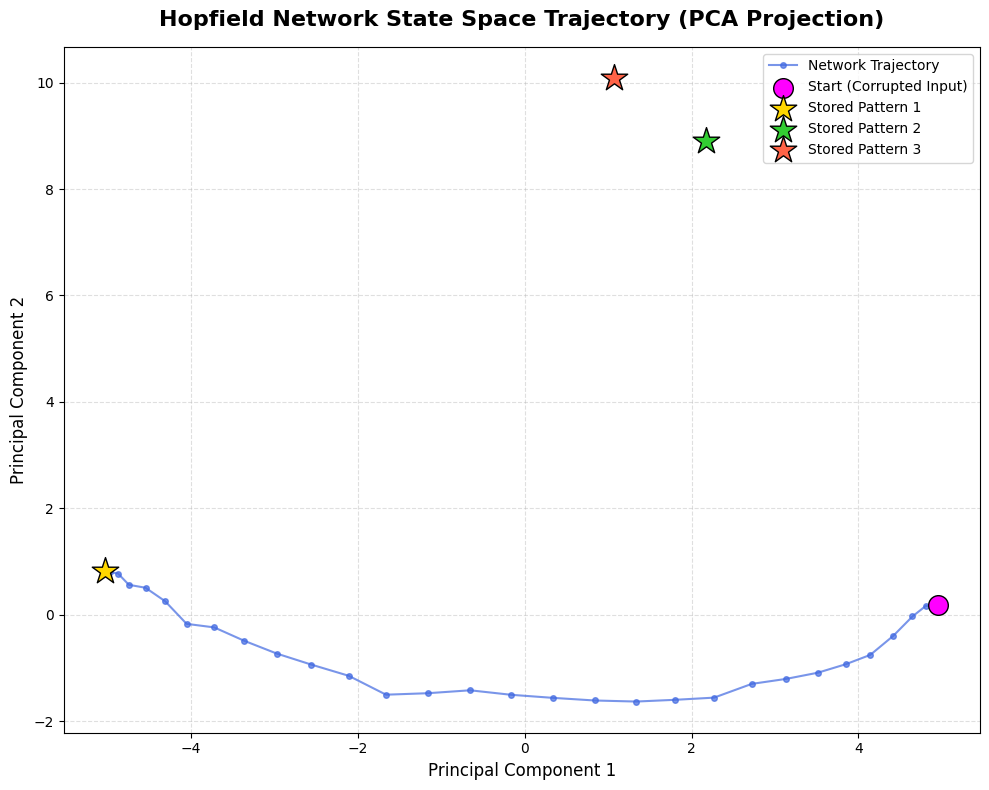

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# 1. Network Setup & Pattern Storage
# ==========================================
N = 100 # Number of neurons
num_patterns = 3

# Create Random Stored Patterns (using bipolar states: -1 or 1)
np.random.seed(42) # Seed for reproducible visualizations
patterns = np.random.choice([-1, 1], size=(num_patterns, N))

# Hebbian Learning: Create Weight Matrix
W = np.zeros((N, N))
for p in patterns:
    # Outer product for Hebbian learning
    W += np.outer(p, p)
np.fill_diagonal(W, 0) # No self-connections
W /= N

# ==========================================
# 2. Corrupting an Input & Running the Network
# ==========================================
# Take the first pattern and flip 30% of its bits to simulate noise
noisy_pattern = np.copy(patterns[0])
flip_indices = np.random.choice(N, size=int(0.30 * N), replace=False)
noisy_pattern[flip_indices] *= -1

# Arrays to keep track of the network's state at each step
trajectory = [np.copy(noisy_pattern)]
current_state = np.copy(noisy_pattern)

# Asynchronous Update Loop
max_iterations = 300
for step in range(max_iterations):
    # Pick a random neuron to update
    neuron_idx = np.random.randint(N)

    # Calculate the local field (dot product of weights and current state)
    local_field = np.dot(W[neuron_idx, :], current_state)

    # Apply the step activation function
    new_state_val = 1 if local_field >= 0 else -1

    # If the state changed, record it in our trajectory
    if current_state[neuron_idx] != new_state_val:
        current_state[neuron_idx] = new_state_val
        trajectory.append(np.copy(current_state))

    # Stop early if we have successfully reconstructed the target pattern
    if np.array_equal(current_state, patterns[0]):
        break

trajectory = np.array(trajectory)

# ==========================================
# 3. Dimensionality Reduction (PCA)
# ==========================================
# We need to project the N-dimensional space to 2D for plotting
pca = PCA(n_components=2)

# Fit PCA on BOTH the stored patterns and the trajectory
# This ensures everything is mapped onto the same spatial axes
all_states = np.vstack((patterns, trajectory))
pca.fit(all_states)

# Transform high-dimensional data to 2D
patterns_2d = pca.transform(patterns)
trajectory_2d = pca.transform(trajectory)

# ==========================================
# 4. Visualization
# ==========================================
plt.figure(figsize=(10, 8))
plt.grid(True, linestyle='--', alpha=0.4)

# Plot the path the network takes
plt.plot(trajectory_2d[:, 0], trajectory_2d[:, 1], marker='.', linestyle='-',
         color='royalblue', markersize=8, alpha=0.7, label='Network Trajectory')

# Highlight the Start Point (The noisy, corrupted input)
plt.scatter(trajectory_2d[0, 0], trajectory_2d[0, 1], color='magenta',
            s=200, zorder=5, edgecolors='black', label='Start (Corrupted Input)')

# Highlight the Stored Patterns (The true memories / targets)
colors = ['gold', 'limegreen', 'tomato']
for i in range(num_patterns):
    plt.scatter(patterns_2d[i, 0], patterns_2d[i, 1], color=colors[i],
                marker='*', s=400, zorder=6, edgecolors='black',
                label=f'Stored Pattern {i+1}')

# Final Formatting
plt.title('Hopfield Network State Space Trajectory (PCA Projection)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

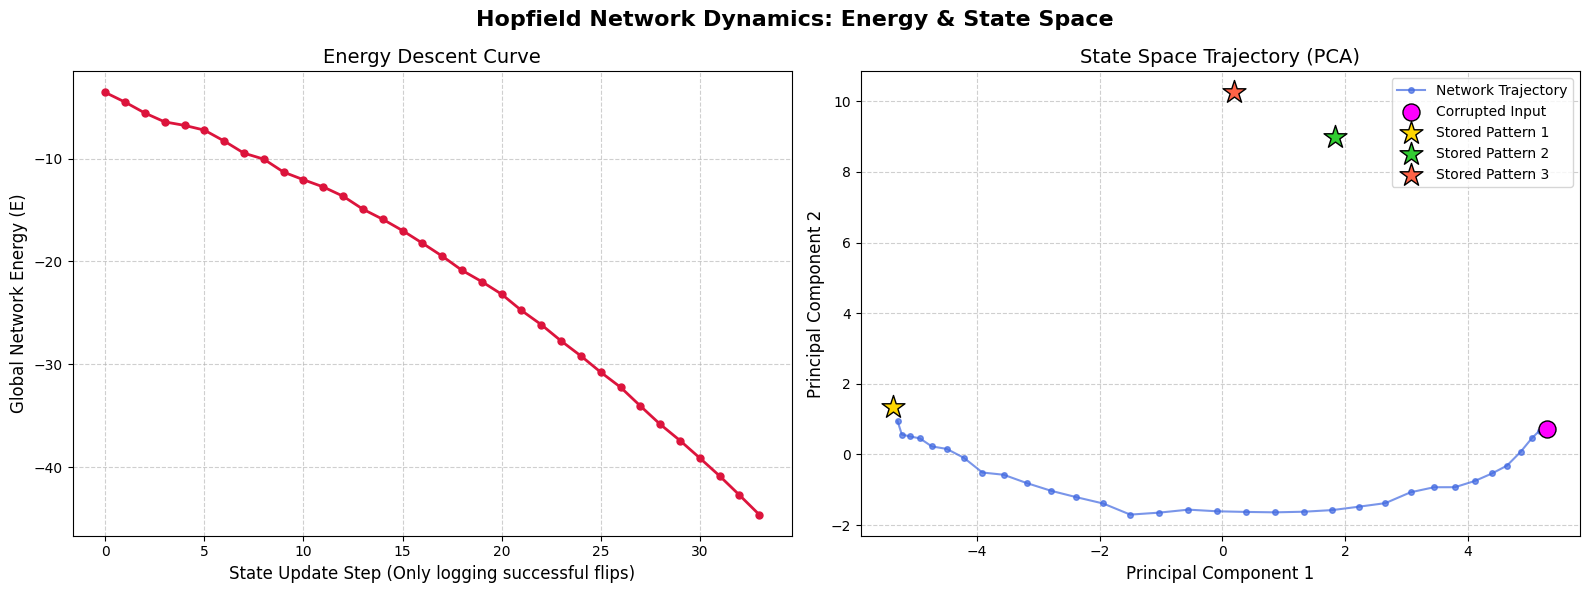

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# 1. Network Setup & Pattern Storage
# ==========================================
N = 100 # Number of neurons
num_patterns = 3

# Create Random Stored Patterns
np.random.seed(42)
patterns = np.random.choice([-1, 1], size=(num_patterns, N))

# Hebbian Learning: Create Weight Matrix
W = np.zeros((N, N))
for p in patterns:
    W += np.outer(p, p)
np.fill_diagonal(W, 0)
W /= N

def calculate_energy(state, weights):
    """
    Calculates the global energy of the network: E = -0.5 * s^T * W * s
    """
    return -0.5 * np.dot(state.T, np.dot(weights, state))

# ==========================================
# 2. Corrupting an Input & Running the Network
# ==========================================
# Flip 35% of the bits of the first pattern to create a noisy input
noisy_pattern = np.copy(patterns[0])
flip_indices = np.random.choice(N, size=int(0.35 * N), replace=False)
noisy_pattern[flip_indices] *= -1

# Trackers for our two visualizations
trajectory = [np.copy(noisy_pattern)]
energy_history = [calculate_energy(noisy_pattern, W)]
current_state = np.copy(noisy_pattern)

# Asynchronous Update Loop
max_iterations = 400
for step in range(max_iterations):
    neuron_idx = np.random.randint(N)

    # Calculate local field and update state
    local_field = np.dot(W[neuron_idx, :], current_state)
    new_state_val = 1 if local_field >= 0 else -1

    # If the state changed, record the new state and its energy
    if current_state[neuron_idx] != new_state_val:
        current_state[neuron_idx] = new_state_val
        trajectory.append(np.copy(current_state))
        energy_history.append(calculate_energy(current_state, W))

    # Stop early if the target pattern is successfully reconstructed
    if np.array_equal(current_state, patterns[0]):
        break

trajectory = np.array(trajectory)

# ==========================================
# 3. Dimensionality Reduction (PCA)
# ==========================================
pca = PCA(n_components=2)
# Fit PCA on both patterns and trajectory to ensure consistent mapping
all_states = np.vstack((patterns, trajectory))
pca.fit(all_states)

patterns_2d = pca.transform(patterns)
trajectory_2d = pca.transform(trajectory)

# ==========================================
# 4. Dual Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hopfield Network Dynamics: Energy & State Space', fontsize=16, fontweight='bold')

# --- Plot 1: Energy Descent Curve ---
axes[0].plot(range(len(energy_history)), energy_history, marker='o',
             color='crimson', linestyle='-', linewidth=2, markersize=5)
axes[0].set_title('Energy Descent Curve', fontsize=14)
axes[0].set_xlabel('State Update Step (Only logging successful flips)', fontsize=12)
axes[0].set_ylabel('Global Network Energy (E)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: State Space Trajectory (PCA) ---
axes[1].plot(trajectory_2d[:, 0], trajectory_2d[:, 1], marker='.',
             linestyle='-', color='royalblue', markersize=8, alpha=0.7, label='Network Trajectory')

# Start point
axes[1].scatter(trajectory_2d[0, 0], trajectory_2d[0, 1], color='magenta',
                s=150, zorder=5, edgecolors='black', label='Corrupted Input')

# Target Memories
colors = ['gold', 'limegreen', 'tomato']
for i in range(num_patterns):
    axes[1].scatter(patterns_2d[i, 0], patterns_2d[i, 1], color=colors[i],
                    marker='*', s=300, zorder=6, edgecolors='black',
                    label=f'Stored Pattern {i+1}')

axes[1].set_title('State Space Trajectory (PCA)', fontsize=14)
axes[1].set_xlabel('Principal Component 1', fontsize=12)
axes[1].set_ylabel('Principal Component 2', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

def create_weight_matrix_perceptron(patterns, max_epochs=1000):
    """
    Stores patterns in a Hopfield Network using the Perceptron Convergence Procedure.
    Expects a list or 2D array of bipolar patterns (1, -1).
    """
    patterns = np.array(patterns)
    num_patterns, num_units = patterns.shape

    # Initialize an N x N weight matrix with zeros
    weights = np.zeros((num_units, num_units))

    # We cycle through the training set until no errors are made
    for epoch in range(max_epochs):
        all_stable = True

        # 1. Cycle through every pattern in the training set
        for p in patterns:

            # 2. Check every neuron individually
            for i in range(num_units):

                # Calculate the local field h_i (excluding self-connections)
                local_field = np.dot(weights[i, :], p)

                # 3. Check for errors:
                # Does the local field have the SAME SIGN as the target pattern state?
                # Mathematically: if h_i * s_i <= 0, the neuron is unstable/wrong.
                if local_field * p[i] <= 0:

                    all_stable = False # We found an error, so we can't stop yet

                    # 4. Apply the Perceptron Update Rule:
                    # Increment weights to push the local field in the correct direction
                    for j in range(num_units):
                        if i != j: # Enforce no self-connections (diagonal stays 0)
                            # Δwij = (1/N) * target_state * input_state
                            weights[i, j] += (1.0 / num_units) * p[i] * p[j]

        # If we made it through all patterns and no neurons were unstable, we are done!
        if all_stable:
            print(f"Success: Perceptron training converged exactly at epoch {epoch + 1}.")
            return weights

    print("Warning: Reached maximum epochs without perfect convergence.")
    return weights



In [6]:
# ==========================================
# Example Usage: Breaking the Hebbian Limit
# ==========================================

N = 10 # 10 neurons
# Generate 4 random patterns to store
# Note: 4 patterns in 10 neurons is a capacity of 0.4N,
# which completely destroys standard Hebbian learning (limit is ~0.15N)
np.random.seed(42)
training_patterns = np.random.choice([-1, 1], size=(4, N))
print("Input training_Patterns\n",training_patterns)

# Compute the weight matrix that stores these patterns

print("Training with Perceptron Rule...")
W_perceptron = create_weight_matrix_perceptron(training_patterns)

# Let's verify! If we input the exact training patterns,
# do they stay perfectly stable (energy minima)?
print("\nVerifying Stored Patterns:")
for idx, p in enumerate(training_patterns):
    # Calculate one synchronous update step
    local_fields = np.dot(W_perceptron, p)
    retrieved_state = np.where(local_fields >= 0, 1, -1)

    # Check if the network state shifted or stayed locked in place
    is_stable = np.array_equal(p, retrieved_state)
    print(f"Pattern {idx + 1} Stable? {is_stable}")

Input training_Patterns
 [[-1  1 -1 -1 -1  1 -1 -1 -1  1]
 [-1 -1 -1 -1  1 -1  1  1  1 -1]
 [ 1 -1  1  1  1  1  1  1  1  1]
 [-1 -1  1  1  1 -1  1 -1 -1 -1]]
Training with Perceptron Rule...
Success: Perceptron training converged exactly at epoch 3.

Verifying Stored Patterns:
Pattern 1 Stable? True
Pattern 2 Stable? True
Pattern 3 Stable? True
Pattern 4 Stable? True


In [7]:
import numpy as np

def retrieve_pattern(weights, input_pattern, max_epochs=100):
    """
    Runs the inference/retrieval process for a Hopfield Network.
    Uses asynchronous updates until the network reaches a stable energy minimum.
    """
    # Make a copy so we don't accidentally overwrite the original input
    current_state = np.copy(input_pattern)
    num_units = len(current_state)

    # We use 'epochs' to represent one full asynchronous pass over all neurons
    for epoch in range(max_epochs):
        # Create an array of all neuron indices and shuffle it
        # This enforces true random asynchronous updates
        neuron_indices = np.arange(num_units)
        np.random.shuffle(neuron_indices)

        state_changed_this_epoch = False

        for i in neuron_indices:
            # 1. Calculate the local field for neuron i (h_i)
            # Mathematically: h_i = sum(w_ij * s_j)
            local_field = np.dot(weights[i, :], current_state)

            # 2. Determine the new state via the step threshold function
            new_state = 1 if local_field >= 0 else -1

            # 3. Update the state and flag if a flip actually occurred
            if current_state[i] != new_state:
                current_state[i] = new_state
                state_changed_this_epoch = True

        # 4. Convergence Check:
        # If we checked every single neuron and none of them wanted to flip,
        # we have successfully reached a local minimum!
        if not state_changed_this_epoch:
            print(f"➔ Inference converged exactly after {epoch + 1} full passes.")
            return current_state

    print("➔ Warning: Reached max iterations without fully converging (might be a limit cycle).")
    return current_state



In [46]:
# ==========================================
# Example Usage: Putting it all together!
# (Assuming W_perceptron is already trained from the previous step)
# ==========================================
print("Input training_Patterns\n",training_patterns)
print("\n--- Testing Inference with Noisy Data ---")

# Let's take the very first pattern we stored and heavily corrupt it (flip 30% of bits)
target_pattern = training_patterns[0]
noisy_input = np.copy(target_pattern)

# Randomly select 10% of the indices to flip
noise_level = 0.2
flip_indices = np.random.choice(N, size=int(noise_level * N), replace=False)
noisy_input[flip_indices] *= -1

print(f"Target Pattern : {target_pattern}")
print(f"Corrupted Input: {noisy_input}")

# Run the inference function!
retrieved_pattern = retrieve_pattern(W_perceptron, noisy_input)

print(f"Recovered State: {retrieved_pattern}")

# Final Verification for the students
success = np.array_equal(target_pattern, retrieved_pattern)
print(f"Successfully reconstructed the memory? {success}")

Input training_Patterns
 [[-1  1 -1 -1 -1  1 -1 -1 -1  1]
 [-1 -1 -1 -1  1 -1  1  1  1 -1]
 [ 1 -1  1  1  1  1  1  1  1  1]
 [-1 -1  1  1  1 -1  1 -1 -1 -1]]

--- Testing Inference with Noisy Data ---
Target Pattern : [-1  1 -1 -1 -1  1 -1 -1 -1  1]
Corrupted Input: [-1  1 -1 -1  1  1 -1 -1  1  1]
➔ Inference converged exactly after 2 full passes.
Recovered State: [-1  1 -1 -1 -1  1 -1 -1 -1  1]
Successfully reconstructed the memory? True
